In [1]:
import numpy as np
import pandas as pd
import pickle
import glob
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

BASE = "/scratch/ariana.l/Stage 4 Link Prediction Model/"

# --- Existence matrices ---
print("Loading matrices...")
F = pd.read_csv(BASE + "stage4_F_existence_phenofield.csv", index_col=0)
P = pd.read_csv(BASE + "stage4_P_existence_gbif_combined.csv", index_col=0)

F_arr = F.values
P_arr = P.values
f_idx = {s: i for i, s in enumerate(F.index)}
p_idx = {s: i for i, s in enumerate(P.index)}

# --- PCA embeddings ---
print("Loading embeddings...")
Vf_df = pd.read_csv(BASE + "stage4_Vf_phenofield.csv", index_col=0)
Vp_df = pd.read_csv(BASE + "stage4_Vp_gbif.csv", index_col=0)

Vf_arr = Vf_df.values
Vp_arr = Vp_df.values
vf_idx = {s: i for i, s in enumerate(Vf_df.index)}
vp_idx = {s: i for i, s in enumerate(Vp_df.index)}

# --- Models ---
print("Loading models...")
with open(BASE + "stage4_A3_logistic.pkl", "rb") as f:
    clf_a3 = pickle.load(f)

with open(BASE + "stage4_A2_logistic.pkl", "rb") as f:
    clf_a2 = pickle.load(f)

# --- PPE curves ---
print("Loading PPE curves...")
flowering_curves = pd.read_parquet("/scratch/ariana.l/ppe-outputs/data/flowering_curves_used.parquet")
activity_curves = pd.read_parquet("/scratch/ariana.l/ppe-outputs/data/activity_curves_used.parquet")

# --- Achillea opportunity surface ---
print("Loading Achillea PPE surface...")
files = sorted(glob.glob("/scratch/ariana.l/ppe-outputs/opportunity_surface/part_*.parquet"))
achillea_data = []
for f in files:
    df = pd.read_parquet(f)
    subset = df[df['species'] == 'Achillea millefolium']
    if len(subset) > 0:
        achillea_data.append(subset)
achillea = pd.concat(achillea_data, ignore_index=True)

# --- Achillea ground truth from GloBI ---
print("Loading ground truth...")
gt = pd.read_csv("/scratch/ariana.l/Stage 4 Link Prediction Model/stage4_globi_conus_broad.csv")
gt = gt[
    (gt['sourceTaxonName'] == 'Achillea millefolium') |
    (gt['targetTaxonName'] == 'Achillea millefolium')
].dropna(subset=['decimalLatitude', 'decimalLongitude'])

print("\nAll done!")
print(f"  F: {F_arr.shape}, P: {P_arr.shape}")
print(f"  Vf: {Vf_arr.shape}, Vp: {Vp_arr.shape}")
print(f"  flowering_curves: {flowering_curves.shape}")
print(f"  activity_curves: {activity_curves.shape}")
print(f"  achillea PPE surface: {achillea.shape}")
print(f"  ground truth obs: {len(gt):,}")

Loading matrices...
Loading embeddings...
Loading models...
Loading PPE curves...


FileNotFoundError: [Errno 2] No such file or directory: '/scratch/ariana.l/ppe-outputs/data/activity_curves_used.parquet'

In [2]:
import subprocess
result = subprocess.run(
    ['find', '/scratch/ariana.l/ppe-outputs', '-name', '*.parquet'],
    capture_output=True, text=True
)
print(result.stdout)

/scratch/ariana.l/ppe-outputs/opportunity_surface/part_01943.parquet
/scratch/ariana.l/ppe-outputs/opportunity_surface/part_01728.parquet
/scratch/ariana.l/ppe-outputs/opportunity_surface/part_01455.parquet
/scratch/ariana.l/ppe-outputs/opportunity_surface/part_06065.parquet
/scratch/ariana.l/ppe-outputs/opportunity_surface/part_05080.parquet
/scratch/ariana.l/ppe-outputs/opportunity_surface/part_05557.parquet
/scratch/ariana.l/ppe-outputs/opportunity_surface/part_04719.parquet
/scratch/ariana.l/ppe-outputs/opportunity_surface/part_02959.parquet
/scratch/ariana.l/ppe-outputs/opportunity_surface/part_04698.parquet
/scratch/ariana.l/ppe-outputs/opportunity_surface/part_06156.parquet
/scratch/ariana.l/ppe-outputs/opportunity_surface/part_03401.parquet
/scratch/ariana.l/ppe-outputs/opportunity_surface/part_04195.parquet
/scratch/ariana.l/ppe-outputs/opportunity_surface/part_02219.parquet
/scratch/ariana.l/ppe-outputs/opportunity_surface/part_03931.parquet
/scratch/ariana.l/ppe-outputs/oppo

In [3]:
sample = pd.read_parquet("/scratch/ariana.l/ppe-outputs/opportunity_surface/part_00354.parquet")
print(sample.shape)
print(sample.columns.tolist())
print(sample.head(3))

(98817, 9)
['species', 'species_id', 'cell_idx', 'centroid_lat', 'centroid_lon', 'week', 'doy', 'p_flowering', 'norm']
                 species  species_id  cell_idx  centroid_lat  centroid_lon  \
0  Aphyllon californicum         361         0         37.75       -122.25   
1  Aphyllon californicum         361         1         38.75        -77.25   
2  Aphyllon californicum         361         2         37.25       -122.25   

   week  doy   p_flowering      norm  
0     0    4  6.797659e-01  0.016541  
1     0    4  7.367809e-14  0.000074  
2     0    4  6.899838e-01  0.015974  


In [4]:
import numpy as np
import pandas as pd
import pickle
import glob
from scipy.stats import vonmises

BASE = "/scratch/ariana.l/Stage 4 Link Prediction Model/"

# --- Existence matrices ---
print("Loading matrices...")
F = pd.read_csv(BASE + "stage4_F_existence_phenofield.csv", index_col=0)
P = pd.read_csv(BASE + "stage4_P_existence_gbif_combined.csv", index_col=0)

F_arr = F.values
P_arr = P.values
f_idx = {s: i for i, s in enumerate(F.index)}
p_idx = {s: i for i, s in enumerate(P.index)}

# --- PCA embeddings ---
print("Loading embeddings...")
Vf_df = pd.read_csv(BASE + "stage4_Vf_phenofield.csv", index_col=0)
Vp_df = pd.read_csv(BASE + "stage4_Vp_gbif.csv", index_col=0)

Vf_arr = Vf_df.values
Vp_arr = Vp_df.values
vf_idx = {s: i for i, s in enumerate(Vf_df.index)}
vp_idx = {s: i for i, s in enumerate(Vp_df.index)}

# --- Models ---
print("Loading models...")
with open(BASE + "stage4_A3_logistic.pkl", "rb") as f:
    clf_a3 = pickle.load(f)
with open(BASE + "stage4_A2_logistic.pkl", "rb") as f:
    clf_a2 = pickle.load(f)

# --- Flowering curves from PPE opportunity surface ---
print("Building flowering curves (averaging norm across cells)...")
files = sorted(glob.glob("/scratch/ariana.l/ppe-outputs/opportunity_surface/part_*.parquet"))
all_curves = []
for f in files:
    df = pd.read_parquet(f, columns=['species', 'week', 'norm'])
    all_curves.append(df.groupby(['species', 'week'])['norm'].mean().reset_index())

flowering_curves = pd.concat(all_curves) \
    .groupby(['species', 'week'])['norm'].mean() \
    .unstack(fill_value=0)
print(f"  flowering_curves: {flowering_curves.shape}")

# --- Activity curves from GBIF (circular KDE) ---
print("Building pollinator activity curves...")

def doy_to_week(doy):
    return ((doy - 1) // 7).clip(0, 51)

GBIF_PATH = "/scratch/ariana.l/Plant Pollinator Initial Analysis/gbif_0007192_observations_v2.csv"
pol_doy = pd.read_csv(GBIF_PATH, usecols=['pollinator_species', 'doy'], low_memory=False)
pol_doy = pol_doy.dropna(subset=['doy', 'pollinator_species'])
pol_doy['week'] = doy_to_week(pol_doy['doy'].astype(int))

week_counts = pol_doy.groupby(['pollinator_species', 'week']).size().unstack(fill_value=0)
activity_curves = week_counts.div(week_counts.sum(axis=1).replace(0, 1), axis=0)
print(f"  activity_curves: {activity_curves.shape}")

# --- Achillea opportunity surface ---
print("Loading Achillea PPE surface...")
achillea_data = []
for f in files:
    df = pd.read_parquet(f)
    subset = df[df['species'] == 'Achillea millefolium']
    if len(subset) > 0:
        achillea_data.append(subset)
achillea = pd.concat(achillea_data, ignore_index=True)
print(f"  achillea: {achillea.shape}")

# --- Ground truth ---
print("Loading ground truth...")
gt = pd.read_csv(BASE + "stage4_globi_conus_broad.csv")
gt = gt[
    (gt['sourceTaxonName'] == 'Achillea millefolium') |
    (gt['targetTaxonName'] == 'Achillea millefolium')
].dropna(subset=['decimalLatitude', 'decimalLongitude'])

print(f"\nAll done! Ground truth obs: {len(gt):,}")

Loading matrices...
Loading embeddings...
Loading models...
Building flowering curves (averaging norm across cells)...
  flowering_curves: (6697, 52)
Building pollinator activity curves...
  activity_curves: (4454, 52)
Loading Achillea PPE surface...


KeyboardInterrupt: 

In [ ]:
import numpy as np
import pandas as pd

PLANT = 'Achillea millefolium'
BIN_SIZE = 0.5
WEEKS = list(range(1, 23))  # weeks 1–22 (Feb–May)

vf_plant = Vf_arr[vf_idx[PLANT]]

# Build bin -> pollinator mapping
print("Building bin -> pollinator mapping...")
bin_to_pollinators = {}
for bin_col in P.columns:
    pols = P.index[P[bin_col] == 1].tolist()
    pols = [p for p in pols if p in vp_idx and p in activity_curves.index]
    if pols:
        bin_to_pollinators[bin_col] = pols
print(f"  Bins with pollinators: {len(bin_to_pollinators):,}")

# Base grid from achillea PPE surface (week-independent geometry)
achillea_grid = achillea[achillea['week'] == 0][['centroid_lat', 'centroid_lon']].drop_duplicates().copy()
achillea_grid['bin'] = (
    ((achillea_grid['centroid_lat'] // BIN_SIZE) * BIN_SIZE).astype(str) + "_" +
    ((achillea_grid['centroid_lon'] // BIN_SIZE) * BIN_SIZE).astype(str)
)
print(f"  Grid cells: {len(achillea_grid):,}")

# Precompute A2 and cache (pol, N) per bin — week-independent
print("Precomputing A2 and caching N values...")
bin_a2_cache = {}
bin_pol_N_cache = {}

for _, cell_row in achillea_grid.iterrows():
    bin_key = cell_row['bin']
    if bin_key in bin_a2_cache:
        continue
    pols = bin_to_pollinators.get(bin_key, [])
    if not pols:
        bin_a2_cache[bin_key] = np.nan
        bin_pol_N_cache[bin_key] = []
        continue

    pol_N_list = []
    a2_preds = []
    for pol in pols:
        N_val = int(F_arr[f_idx[PLANT]] @ P_arr[p_idx[pol]]) if PLANT in f_idx and pol in p_idx else 0
        feat = np.concatenate([vf_plant, Vp_arr[vp_idx[pol]], [N_val]])
        a2_preds.append(clf_a2.predict_proba(feat.reshape(1, -1))[0, 1])
        pol_N_list.append((pol, N_val))

    bin_a2_cache[bin_key] = np.mean(a2_preds)
    bin_pol_N_cache[bin_key] = pol_N_list

print("Computing A3 per week...")
results = []
for week in WEEKS:
    if week % 4 == 0:
        print(f"  week {week}/22...")
    f_w = flowering_curves.loc[PLANT, week] if week in flowering_curves.columns else 0

    for _, cell_row in achillea_grid.iterrows():
        bin_key = cell_row['bin']
        pol_N_list = bin_pol_N_cache.get(bin_key, [])

        if not pol_N_list:
            results.append({
                'lat': cell_row['centroid_lat'],
                'lon': cell_row['centroid_lon'],
                'week': week,
                'pred_a2': np.nan,
                'pred_a3': np.nan
            })
            continue

        week_preds = []
        for pol, N_val in pol_N_list:
            a_w = activity_curves.loc[pol, week] if week in activity_curves.columns else 0
            delta = min(f_w, a_w)
            feat = np.concatenate([vf_plant, Vp_arr[vp_idx[pol]], [N_val, delta]])
            week_preds.append(clf_a3.predict_proba(feat.reshape(1, -1))[0, 1])

        results.append({
            'lat': cell_row['centroid_lat'],
            'lon': cell_row['centroid_lon'],
            'week': week,
            'pred_a2': bin_a2_cache[bin_key],
            'pred_a3': np.mean(week_preds)
        })

pred_df = pd.DataFrame(results)
pred_df.to_parquet(BASE + "pred_df_weeks1_22.parquet", index=False)
print(f"\nDone! Shape: {pred_df.shape}")
print(pred_df.dropna().describe())

In [ ]:
# Align F and P to common bins before computing N
common_bins = F.columns.intersection(P.columns)
F_common = F[common_bins]
P_common = P[common_bins]

F_common_arr = F_common.values
P_common_arr = P_common.values
f_common_idx = {s: i for i, s in enumerate(F_common.index)}
p_common_idx = {s: i for i, s in enumerate(P_common.index)}

print(f"Common bins: {len(common_bins):,}")
print(f"F_common: {F_common_arr.shape}, P_common: {P_common_arr.shape}")

In [ ]:
import numpy as np
import pandas as pd

PLANT = 'Achillea millefolium'
BIN_SIZE = 0.5
WEEKS = list(range(1, 23))

vf_plant = Vf_arr[vf_idx[PLANT]]

# Build bin -> pollinator mapping
print("Building bin -> pollinator mapping...")
bin_to_pollinators = {}
for bin_col in P.columns:
    pols = P.index[P[bin_col] == 1].tolist()
    pols = [p for p in pols if p in vp_idx and p in activity_curves.index]
    if pols:
        bin_to_pollinators[bin_col] = pols
print(f"  Bins with pollinators: {len(bin_to_pollinators):,}")

# Base grid from achillea PPE surface
achillea_grid = achillea[achillea['week'] == 0][['centroid_lat', 'centroid_lon']].drop_duplicates().copy()
achillea_grid['bin'] = (
    ((achillea_grid['centroid_lat'] // BIN_SIZE) * BIN_SIZE).astype(str) + "_" +
    ((achillea_grid['centroid_lon'] // BIN_SIZE) * BIN_SIZE).astype(str)
)
print(f"  Grid cells: {len(achillea_grid):,}")

# Precompute A2 and cache (pol, N) per bin
print("Precomputing A2 and caching N values...")
bin_a2_cache = {}
bin_pol_N_cache = {}

for _, cell_row in achillea_grid.iterrows():
    bin_key = cell_row['bin']
    if bin_key in bin_a2_cache:
        continue
    pols = bin_to_pollinators.get(bin_key, [])
    if not pols:
        bin_a2_cache[bin_key] = np.nan
        bin_pol_N_cache[bin_key] = []
        continue

    pol_N_list = []
    a2_preds = []
    for pol in pols:
        N_val = int(F_common_arr[f_common_idx[PLANT]] @ P_common_arr[p_common_idx[pol]]) \
                if PLANT in f_common_idx and pol in p_common_idx else 0
        feat = np.concatenate([vf_plant, Vp_arr[vp_idx[pol]], [N_val]])
        a2_preds.append(clf_a2.predict_proba(feat.reshape(1, -1))[0, 1])
        pol_N_list.append((pol, N_val))

    bin_a2_cache[bin_key] = np.mean(a2_preds)
    bin_pol_N_cache[bin_key] = pol_N_list

# Compute A3 per week
print("Computing A3 per week...")
results = []
for week in WEEKS:
    if week % 4 == 0:
        print(f"  week {week}/22...")
    f_w = flowering_curves.loc[PLANT, week] if week in flowering_curves.columns else 0

    for _, cell_row in achillea_grid.iterrows():
        bin_key = cell_row['bin']
        pol_N_list = bin_pol_N_cache.get(bin_key, [])

        if not pol_N_list:
            results.append({
                'lat': cell_row['centroid_lat'],
                'lon': cell_row['centroid_lon'],
                'week': week,
                'pred_a2': np.nan,
                'pred_a3': np.nan
            })
            continue

        week_preds = []
        for pol, N_val in pol_N_list:
            a_w = activity_curves.loc[pol, week] if week in activity_curves.columns else 0
            delta = min(f_w, a_w)
            feat = np.concatenate([vf_plant, Vp_arr[vp_idx[pol]], [N_val, delta]])
            week_preds.append(clf_a3.predict_proba(feat.reshape(1, -1))[0, 1])

        results.append({
            'lat': cell_row['centroid_lat'],
            'lon': cell_row['centroid_lon'],
            'week': week,
            'pred_a2': bin_a2_cache[bin_key],
            'pred_a3': np.mean(week_preds)
        })

pred_df = pd.DataFrame(results)
pred_df.to_parquet(BASE + "pred_df_weeks1_22.parquet", index=False)
print(f"\nDone! Shape: {pred_df.shape}")
print(pred_df.dropna().describe())

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

PLANT = 'Achillea millefolium'

# --- Representative weeks for spatial maps (evenly spaced across Feb-May) ---
SPATIAL_WEEKS = {4: 'Feb', 9: 'Mar', 13: 'Apr', 18: 'May'}

# --- Hovmoller: 1° latitude bands ---
pred_df['lat_band'] = np.floor(pred_df['lat']).astype(int)
hovmoller_a2 = pred_df.groupby(['lat_band', 'week'])['pred_a2'].mean().unstack(fill_value=np.nan)
hovmoller_a3 = pred_df.groupby(['lat_band', 'week'])['pred_a3'].mean().unstack(fill_value=np.nan)

# --- Layout ---
fig = plt.figure(figsize=(24, 16))
gs = gridspec.GridSpec(
    3, 5,
    height_ratios=[1.2, 1.2, 1.0],
    width_ratios=[1, 1, 1, 1, 0.05],
    hspace=0.45, wspace=0.12
)

CONUS_LON = (-125, -66)
CONUS_LAT = (24, 50)
CMAP_PRED = 'RdYlGn'
CMAP_DIFF = 'RdBu_r'

# ── Row 0: Spatial maps ──────────────────────────────────────────────────────
row0_axes = []
for col, (week, month) in enumerate(SPATIAL_WEEKS.items()):
    ax = fig.add_subplot(gs[0, col])
    row0_axes.append(ax)
    week_data = pred_df[pred_df['week'] == week]

    if col == 0:
        # Ground truth scatter
        sc = ax.scatter(gt['decimalLongitude'], gt['decimalLatitude'],
                        c='#2d6a4f', s=6, alpha=0.5, zorder=2)
        ax.set_facecolor('#f0f0f0')
        if col == 0:
            ax.set_ylabel('Ground Truth\n(GloBI)', fontsize=9, fontweight='bold', labelpad=6)
    elif col == 1:
        sc = ax.scatter(week_data['lon'], week_data['lat'],
                        c=week_data['pred_a2'], cmap=CMAP_PRED,
                        s=6, vmin=0.6, vmax=1.0, alpha=0.8)
        if col == 1:
            ax.set_ylabel('A2 (Spatial\nCo-occurrence)', fontsize=9, fontweight='bold', labelpad=6)
    elif col == 2:
        sc = ax.scatter(week_data['lon'], week_data['lat'],
                        c=week_data['pred_a3'], cmap=CMAP_PRED,
                        s=6, vmin=0.6, vmax=1.0, alpha=0.8)
        if col == 2:
            ax.set_ylabel('ANTHEIA A3\n(+ PPE Δ)', fontsize=9, fontweight='bold', labelpad=6)
    else:
        # Difference map for this week
        diff = week_data['pred_a3'].values - week_data['pred_a2'].values
        sc = ax.scatter(week_data['lon'], week_data['lat'],
                        c=diff, cmap=CMAP_DIFF,
                        s=6, vmin=-0.3, vmax=0.3, alpha=0.8)
        if col == 3:
            ax.set_ylabel('A3 − A2\n(Difference)', fontsize=9, fontweight='bold', labelpad=6)

    ax.set_xlim(*CONUS_LON); ax.set_ylim(*CONUS_LAT)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(month, fontsize=11, fontweight='bold')

# ── Row 1: Hovmoller ─────────────────────────────────────────────────────────
ax_hov_a2 = fig.add_subplot(gs[1, :2])
ax_hov_a3 = fig.add_subplot(gs[1, 2:4])

for ax, data, label in [
    (ax_hov_a2, hovmoller_a2, 'A2 — Spatial Co-occurrence'),
    (ax_hov_a3, hovmoller_a3, 'ANTHEIA A3 — With PPE Δ')
]:
    im = ax.imshow(
        data.sort_index(ascending=False),
        aspect='auto', cmap=CMAP_PRED,
        vmin=0.6, vmax=1.0,
        extent=[1, 22, data.index.min() - 0.5, data.index.max() + 0.5]
    )
    ax.set_xlabel('Week', fontsize=9)
    ax.set_ylabel('Latitude (°N)', fontsize=9)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xticks([1, 4, 9, 13, 18, 22])
    ax.set_xticklabels(['Wk1\n(Jan)', 'Feb', 'Mar', 'Apr', 'May', 'Wk22'])

# ── Row 2: Full difference map (averaged across weeks 1-22) ─────────────────
ax_diff = fig.add_subplot(gs[2, :4])
diff_mean = pred_df.groupby(['lat', 'lon']).apply(
    lambda x: (x['pred_a3'] - x['pred_a2']).mean()
).reset_index(name='diff_mean')

sc_diff = ax_diff.scatter(
    diff_mean['lon'], diff_mean['lat'],
    c=diff_mean['diff_mean'], cmap=CMAP_DIFF,
    s=8, vmin=-0.3, vmax=0.3, alpha=0.9
)
ax_diff.set_xlim(*CONUS_LON); ax_diff.set_ylim(*CONUS_LAT)
ax_diff.set_aspect('equal'); ax_diff.set_xticks([]); ax_diff.set_yticks([])
ax_diff.set_title('Mean A3 − A2 Difference (Weeks 1–22)', fontsize=11, fontweight='bold')

# ── Colorbars ────────────────────────────────────────────────────────────────
cax = fig.add_subplot(gs[:2, 4])
sm_pred = plt.cm.ScalarMappable(cmap=CMAP_PRED, norm=mcolors.Normalize(0.6, 1.0))
sm_pred.set_array([])
plt.colorbar(sm_pred, cax=cax, label='P(interaction)')

# Difference colorbar alongside row 2
cax2 = fig.add_axes([0.92, 0.08, 0.015, 0.22])
sm_diff = plt.cm.ScalarMappable(cmap=CMAP_DIFF, norm=mcolors.Normalize(-0.3, 0.3))
sm_diff.set_array([])
plt.colorbar(sm_diff, cax=cax2, label='ΔP (A3 − A2)')

fig.suptitle('Achillea millefolium — ANTHEIA Interaction Predictions',
             fontsize=15, fontweight='bold', y=1.01)

plt.savefig(BASE + "antheia_combined_figure.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

PLANT = 'Achillea millefolium'
SPATIAL_WEEKS = {4: 'Feb', 9: 'Mar', 13: 'Apr', 18: 'May'}

# --- Hovmoller ---
pred_df['lat_band'] = np.floor(pred_df['lat']).astype(int)
hovmoller_a2 = pred_df.groupby(['lat_band', 'week'])['pred_a2'].mean().unstack(fill_value=np.nan)
hovmoller_a3 = pred_df.groupby(['lat_band', 'week'])['pred_a3'].mean().unstack(fill_value=np.nan)

# --- Layout: 3 rows, 6 cols ---
# Row 0: GT(1) | A2(1) | A3×4 months
# Row 1: Hovmoller A2 (3 cols) | Hovmoller A3 (3 cols)
# Row 2: Difference map (6 cols)
fig = plt.figure(figsize=(26, 16))
gs = gridspec.GridSpec(
    3, 7,
    height_ratios=[1.2, 1.2, 1.0],
    width_ratios=[1, 1, 1, 1, 1, 1, 0.05],
    hspace=0.45, wspace=0.12
)

CONUS_LON = (-125, -66)
CONUS_LAT = (24, 50)
CMAP_PRED = 'RdYlGn'
CMAP_DIFF = 'RdBu_r'

# ── Row 0: Spatial maps ──────────────────────────────────────────────────────

# Col 0: Ground Truth (static)
ax_gt = fig.add_subplot(gs[0, 0])
ax_gt.scatter(gt['decimalLongitude'], gt['decimalLatitude'],
              c='#2d6a4f', s=6, alpha=0.5)
ax_gt.set_xlim(*CONUS_LON); ax_gt.set_ylim(*CONUS_LAT)
ax_gt.set_aspect('equal'); ax_gt.set_xticks([]); ax_gt.set_yticks([])
ax_gt.set_title('Ground Truth\n(GloBI)', fontsize=10, fontweight='bold')

# Col 1: A2 (static)
ax_a2 = fig.add_subplot(gs[0, 1])
a2_week1 = pred_df[pred_df['week'] == 1]  # any week — A2 is identical across weeks
ax_a2.scatter(a2_week1['lon'], a2_week1['lat'],
              c=a2_week1['pred_a2'], cmap=CMAP_PRED,
              s=6, vmin=0.6, vmax=1.0, alpha=0.8)
ax_a2.set_xlim(*CONUS_LON); ax_a2.set_ylim(*CONUS_LAT)
ax_a2.set_aspect('equal'); ax_a2.set_xticks([]); ax_a2.set_yticks([])
ax_a2.set_title('A2 — Spatial\nCo-occurrence', fontsize=10, fontweight='bold')

# Cols 2–5: A3 across Feb, Mar, Apr, May
for col, (week, month) in enumerate(SPATIAL_WEEKS.items()):
    ax = fig.add_subplot(gs[0, col + 2])
    week_data = pred_df[pred_df['week'] == week]
    sc = ax.scatter(week_data['lon'], week_data['lat'],
                    c=week_data['pred_a3'], cmap=CMAP_PRED,
                    s=6, vmin=0.6, vmax=1.0, alpha=0.8)
    ax.set_xlim(*CONUS_LON); ax.set_ylim(*CONUS_LAT)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'ANTHEIA A3\n{month}', fontsize=10, fontweight='bold')

# ── Row 1: Hovmoller ─────────────────────────────────────────────────────────
ax_hov_a2 = fig.add_subplot(gs[1, :3])
ax_hov_a3 = fig.add_subplot(gs[1, 3:6])

for ax, data, label in [
    (ax_hov_a2, hovmoller_a2, 'A2 — Spatial Co-occurrence'),
    (ax_hov_a3, hovmoller_a3, 'ANTHEIA A3 — With PPE Δ')
]:
    im = ax.imshow(
        data.sort_index(ascending=False),
        aspect='auto', cmap=CMAP_PRED,
        vmin=0.6, vmax=1.0,
        extent=[1, 22, data.index.min() - 0.5, data.index.max() + 0.5]
    )
    ax.set_xlabel('Week', fontsize=9)
    ax.set_ylabel('Latitude (°N)', fontsize=9)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xticks([1, 4, 9, 13, 18, 22])
    ax.set_xticklabels(['Wk1', 'Feb', 'Mar', 'Apr', 'May', 'Wk22'])

# ── Row 2: Mean difference map ───────────────────────────────────────────────
ax_diff = fig.add_subplot(gs[2, :6])
diff_mean = pred_df.groupby(['lat', 'lon']).apply(
    lambda x: (x['pred_a3'] - x['pred_a2']).mean()
).reset_index(name='diff_mean')

sc_diff = ax_diff.scatter(
    diff_mean['lon'], diff_mean['lat'],
    c=diff_mean['diff_mean'], cmap=CMAP_DIFF,
    s=8, vmin=-0.3, vmax=0.3, alpha=0.9
)
ax_diff.set_xlim(*CONUS_LON); ax_diff.set_ylim(*CONUS_LAT)
ax_diff.set_aspect('equal'); ax_diff.set_xticks([]); ax_diff.set_yticks([])
ax_diff.set_title('Mean A3 − A2 Difference (Weeks 1–22)', fontsize=11, fontweight='bold')

# ── Colorbars ────────────────────────────────────────────────────────────────
cax = fig.add_subplot(gs[:2, 6])
sm_pred = plt.cm.ScalarMappable(cmap=CMAP_PRED, norm=mcolors.Normalize(0.6, 1.0))
sm_pred.set_array([])
plt.colorbar(sm_pred, cax=cax, label='P(interaction)')

cax2 = fig.add_axes([0.92, 0.08, 0.015, 0.22])
sm_diff = plt.cm.ScalarMappable(cmap=CMAP_DIFF, norm=mcolors.Normalize(-0.3, 0.3))
sm_diff.set_array([])
plt.colorbar(sm_diff, cax=cax2, label='ΔP (A3 − A2)')

fig.suptitle('Achillea millefolium — ANTHEIA Interaction Predictions',
             fontsize=15, fontweight='bold', y=1.01)

plt.savefig(BASE + "antheia_combined_figure_v2.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [ ]:
# Check how much A3 actually varies across weeks per lat band
weekly_mean = pred_df.groupby('week')['pred_a3'].mean()
print("A3 mean per week:")
print(weekly_mean.to_string())

print("\nA3 std per week:")
print(pred_df.groupby('week')['pred_a3'].std().to_string())

# Also check delta values
PLANT = 'Achillea millefolium'
f_w_vals = {w: flowering_curves.loc[PLANT, w] if w in flowering_curves.columns else 0 
            for w in range(1, 23)}
print("\nFlowering curve values weeks 1-22:")
for w, v in f_w_vals.items():
    print(f"  week {w:2d}: {v:.4f}")

In [ ]:
# Check activity curve scale vs flowering curve scale
sample_pol = activity_curves.index[0]
print(f"Sample pollinator: {sample_pol}")
print(f"Activity curve weeks 1-22: {activity_curves.loc[sample_pol, list(range(1,23))].values}")
print(f"\nActivity curve sum: {activity_curves.loc[sample_pol].sum():.3f}")
print(f"Flowering curve sum weeks 1-22: {sum(f_w_vals.values()):.3f}")
print(f"\nFlowering curve max: {max(f_w_vals.values()):.4f}")
print(f"Activity curve max (this pollinator): {activity_curves.loc[sample_pol].max():.4f}")

In [ ]:
PLANT = 'Achillea millefolium'
BIN_SIZE = 0.5
WEEKS = list(range(1, 53))  # full year

vf_plant = Vf_arr[vf_idx[PLANT]]

print("Building bin -> pollinator mapping...")
bin_to_pollinators = {}
for bin_col in P.columns:
    pols = P.index[P[bin_col] == 1].tolist()
    pols = [p for p in pols if p in vp_idx and p in activity_curves.index]
    if pols:
        bin_to_pollinators[bin_col] = pols
print(f"  Bins with pollinators: {len(bin_to_pollinators):,}")

achillea_grid = achillea[achillea['week'] == 0][['centroid_lat', 'centroid_lon']].drop_duplicates().copy()
achillea_grid['bin'] = (
    ((achillea_grid['centroid_lat'] // BIN_SIZE) * BIN_SIZE).astype(str) + "_" +
    ((achillea_grid['centroid_lon'] // BIN_SIZE) * BIN_SIZE).astype(str)
)
print(f"  Grid cells: {len(achillea_grid):,}")

print("Precomputing A2 and caching N values...")
bin_a2_cache = {}
bin_pol_N_cache = {}

for _, cell_row in achillea_grid.iterrows():
    bin_key = cell_row['bin']
    if bin_key in bin_a2_cache:
        continue
    pols = bin_to_pollinators.get(bin_key, [])
    if not pols:
        bin_a2_cache[bin_key] = np.nan
        bin_pol_N_cache[bin_key] = []
        continue

    pol_N_list = []
    a2_preds = []
    for pol in pols:
        N_val = int(F_common_arr[f_common_idx[PLANT]] @ P_common_arr[p_common_idx[pol]]) \
                if PLANT in f_common_idx and pol in p_common_idx else 0
        feat = np.concatenate([vf_plant, Vp_arr[vp_idx[pol]], [N_val]])
        a2_preds.append(clf_a2.predict_proba(feat.reshape(1, -1))[0, 1])
        pol_N_list.append((pol, N_val))

    bin_a2_cache[bin_key] = np.mean(a2_preds)
    bin_pol_N_cache[bin_key] = pol_N_list

print("Computing A3 per week (full year)...")
results = []
for week in WEEKS:
    if week % 8 == 0:
        print(f"  week {week}/52...")
    f_w = flowering_curves.loc[PLANT, week] if week in flowering_curves.columns else 0

    for _, cell_row in achillea_grid.iterrows():
        bin_key = cell_row['bin']
        pol_N_list = bin_pol_N_cache.get(bin_key, [])

        if not pol_N_list:
            results.append({'lat': cell_row['centroid_lat'], 'lon': cell_row['centroid_lon'],
                            'week': week, 'pred_a2': np.nan, 'pred_a3': np.nan})
            continue

        week_preds = []
        for pol, N_val in pol_N_list:
            a_w = activity_curves.loc[pol, week] if week in activity_curves.columns else 0
            delta = min(f_w, a_w)
            feat = np.concatenate([vf_plant, Vp_arr[vp_idx[pol]], [N_val, delta]])
            week_preds.append(clf_a3.predict_proba(feat.reshape(1, -1))[0, 1])

        results.append({'lat': cell_row['centroid_lat'], 'lon': cell_row['centroid_lon'],
                        'week': week, 'pred_a2': bin_a2_cache[bin_key],
                        'pred_a3': np.mean(week_preds)})

pred_df = pd.DataFrame(results)
pred_df.to_parquet(BASE + "pred_df_weeks1_52.parquet", index=False)
print(f"\nDone! Shape: {pred_df.shape}")
print(pred_df.dropna().describe())

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

PLANT = 'Achillea millefolium'

# Representative weeks: Spring, Summer, Fall, Winter
SPATIAL_WEEKS = {13: 'Spring\n(Wk13)', 26: 'Summer\n(Wk26)', 39: 'Fall\n(Wk39)', 52: 'Winter\n(Wk52)'}

# --- Hovmoller ---
pred_df['lat_band'] = np.floor(pred_df['lat']).astype(int)
hovmoller_a2 = pred_df.groupby(['lat_band', 'week'])['pred_a2'].mean().unstack(fill_value=np.nan)
hovmoller_a3 = pred_df.groupby(['lat_band', 'week'])['pred_a3'].mean().unstack(fill_value=np.nan)

# --- Layout: 3 rows, 7 cols ---
fig = plt.figure(figsize=(26, 16))
gs = gridspec.GridSpec(
    3, 7,
    height_ratios=[1.2, 1.2, 1.0],
    width_ratios=[1, 1, 1, 1, 1, 1, 0.05],
    hspace=0.45, wspace=0.12
)

CONUS_LON = (-125, -66)
CONUS_LAT = (24, 50)
CMAP_PRED = 'RdYlGn'
CMAP_DIFF = 'RdBu_r'

# ── Row 0: Spatial maps ──────────────────────────────────────────────────────

# Col 0: Ground Truth (static)
ax_gt = fig.add_subplot(gs[0, 0])
ax_gt.scatter(gt['decimalLongitude'], gt['decimalLatitude'],
              c='#2d6a4f', s=6, alpha=0.5)
ax_gt.set_xlim(*CONUS_LON); ax_gt.set_ylim(*CONUS_LAT)
ax_gt.set_aspect('equal'); ax_gt.set_xticks([]); ax_gt.set_yticks([])
ax_gt.set_title('Ground Truth\n(GloBI)', fontsize=10, fontweight='bold')

# Col 1: A2 (static)
ax_a2 = fig.add_subplot(gs[0, 1])
a2_data = pred_df[pred_df['week'] == 1]
ax_a2.scatter(a2_data['lon'], a2_data['lat'],
              c=a2_data['pred_a2'], cmap=CMAP_PRED,
              s=6, vmin=0.6, vmax=1.0, alpha=0.8)
ax_a2.set_xlim(*CONUS_LON); ax_a2.set_ylim(*CONUS_LAT)
ax_a2.set_aspect('equal'); ax_a2.set_xticks([]); ax_a2.set_yticks([])
ax_a2.set_title('A2 — Spatial\nCo-occurrence', fontsize=10, fontweight='bold')

# Cols 2–5: A3 across 4 seasons
for col, (week, label) in enumerate(SPATIAL_WEEKS.items()):
    ax = fig.add_subplot(gs[0, col + 2])
    week_data = pred_df[pred_df['week'] == week]
    ax.scatter(week_data['lon'], week_data['lat'],
               c=week_data['pred_a3'], cmap=CMAP_PRED,
               s=6, vmin=0.6, vmax=1.0, alpha=0.8)
    ax.set_xlim(*CONUS_LON); ax.set_ylim(*CONUS_LAT)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'ANTHEIA A3\n{label}', fontsize=10, fontweight='bold')

# ── Row 1: Hovmoller ─────────────────────────────────────────────────────────
ax_hov_a2 = fig.add_subplot(gs[1, :3])
ax_hov_a3 = fig.add_subplot(gs[1, 3:6])

month_ticks = [1, 5, 9, 14, 18, 22, 27, 31, 35, 40, 44, 48, 52]
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec','']

for ax, data, label in [
    (ax_hov_a2, hovmoller_a2, 'A2 — Spatial Co-occurrence'),
    (ax_hov_a3, hovmoller_a3, 'ANTHEIA A3 — With PPE Δ')
]:
    ax.imshow(
        data.sort_index(ascending=False),
        aspect='auto', cmap=CMAP_PRED,
        vmin=0.6, vmax=1.0,
        extent=[1, 52, data.index.min() - 0.5, data.index.max() + 0.5]
    )
    ax.set_xlabel('Month', fontsize=9)
    ax.set_ylabel('Latitude (°N)', fontsize=9)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.set_xticks(month_ticks)
    ax.set_xticklabels(month_labels, fontsize=8)

# ── Row 2: Mean difference map ───────────────────────────────────────────────
ax_diff = fig.add_subplot(gs[2, :6])
diff_mean = pred_df.groupby(['lat', 'lon']).apply(
    lambda x: (x['pred_a3'] - x['pred_a2']).mean()
).reset_index(name='diff_mean')

ax_diff.scatter(
    diff_mean['lon'], diff_mean['lat'],
    c=diff_mean['diff_mean'], cmap=CMAP_DIFF,
    s=8, vmin=-0.3, vmax=0.3, alpha=0.9
)
ax_diff.set_xlim(*CONUS_LON); ax_diff.set_ylim(*CONUS_LAT)
ax_diff.set_aspect('equal'); ax_diff.set_xticks([]); ax_diff.set_yticks([])
ax_diff.set_title('Mean A3 − A2 Difference (Full Year)', fontsize=11, fontweight='bold')

# ── Colorbars ────────────────────────────────────────────────────────────────
cax = fig.add_subplot(gs[:2, 6])
sm_pred = plt.cm.ScalarMappable(cmap=CMAP_PRED, norm=mcolors.Normalize(0.6, 1.0))
sm_pred.set_array([])
plt.colorbar(sm_pred, cax=cax, label='P(interaction)')

cax2 = fig.add_axes([0.92, 0.08, 0.015, 0.22])
sm_diff = plt.cm.ScalarMappable(cmap=CMAP_DIFF, norm=mcolors.Normalize(-0.3, 0.3))
sm_diff.set_array([])
plt.colorbar(sm_diff, cax=cax2, label='ΔP (A3 − A2)')

fig.suptitle('Achillea millefolium — ANTHEIA Interaction Predictions (Full Year)',
             fontsize=15, fontweight='bold', y=1.01)

plt.savefig(BASE + "antheia_combined_figure_v3.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [ ]:
# Compute delta per bin per week
PLANT = 'Achillea millefolium'
WEEKS = list(range(1, 53))

print("Computing delta per bin per week...")
delta_results = []

for week in WEEKS:
    if week % 8 == 0:
        print(f"  week {week}/52...")
    f_w = flowering_curves.loc[PLANT, week] if week in flowering_curves.columns else 0

    for _, cell_row in achillea_grid.iterrows():
        bin_key = cell_row['bin']
        pol_N_list = bin_pol_N_cache.get(bin_key, [])

        if not pol_N_list:
            delta_results.append({
                'lat': cell_row['centroid_lat'],
                'lon': cell_row['centroid_lon'],
                'week': week,
                'delta': np.nan
            })
            continue

        bin_deltas = []
        for pol, N_val in pol_N_list:
            a_w = activity_curves.loc[pol, week] if week in activity_curves.columns else 0
            bin_deltas.append(min(f_w, a_w))

        delta_results.append({
            'lat': cell_row['centroid_lat'],
            'lon': cell_row['centroid_lon'],
            'week': week,
            'delta': np.mean(bin_deltas)
        })

delta_df = pd.DataFrame(delta_results)
delta_df.to_parquet(BASE + "delta_df_weeks1_52.parquet", index=False)
print(f"\nDone! Shape: {delta_df.shape}")
print(delta_df.dropna().describe())

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd

PLANT = 'Achillea millefolium'
SPATIAL_WEEKS = {13: 'Spring\n(Wk13)', 26: 'Summer\n(Wk26)', 39: 'Fall\n(Wk39)', 52: 'Winter\n(Wk52)'}

# --- Hovmoller: delta (latitude × week) ---
delta_df['lat_band'] = np.floor(delta_df['lat']).astype(int)
hovmoller_delta = delta_df.groupby(['lat_band', 'week'])['delta'].mean().unstack(fill_value=np.nan)

# --- A2 latitude profile (static) ---
a2_profile = pred_df.groupby('lat')['pred_a2'].mean().sort_index()

# --- Layout ---
fig = plt.figure(figsize=(26, 16), facecolor='white')
gs = gridspec.GridSpec(
    3, 7,
    height_ratios=[1.2, 1.2, 1.0],
    width_ratios=[1, 1, 1, 1, 1, 1, 0.05],
    hspace=0.45, wspace=0.15
)

CONUS_LON = (-125, -66)
CONUS_LAT = (24, 50)
CMAP_PRED = 'RdYlGn'
CMAP_DELTA = 'YlOrRd'
CMAP_DIFF = 'RdBu_r'

# ── Row 0: Spatial maps ──────────────────────────────────────────────────────

# Col 0: Ground Truth
ax_gt = fig.add_subplot(gs[0, 0])
ax_gt.set_facecolor('white')
ax_gt.scatter(gt['decimalLongitude'], gt['decimalLatitude'],
              c='#2d6a4f', s=6, alpha=0.5)
ax_gt.set_xlim(*CONUS_LON); ax_gt.set_ylim(*CONUS_LAT)
ax_gt.set_aspect('equal'); ax_gt.set_xticks([]); ax_gt.set_yticks([])
ax_gt.set_title('Ground Truth\n(GloBI)', fontsize=10, fontweight='bold')

# Col 1: A2 static
ax_a2 = fig.add_subplot(gs[0, 1])
ax_a2.set_facecolor('white')
a2_data = pred_df[pred_df['week'] == 1]
ax_a2.scatter(a2_data['lon'], a2_data['lat'],
              c=a2_data['pred_a2'], cmap=CMAP_PRED,
              s=6, vmin=0.6, vmax=1.0, alpha=0.8)
ax_a2.set_xlim(*CONUS_LON); ax_a2.set_ylim(*CONUS_LAT)
ax_a2.set_aspect('equal'); ax_a2.set_xticks([]); ax_a2.set_yticks([])
ax_a2.set_title('A2 — Spatial\nCo-occurrence', fontsize=10, fontweight='bold')

# Cols 2–5: Delta across 4 seasons
for col, (week, label) in enumerate(SPATIAL_WEEKS.items()):
    ax = fig.add_subplot(gs[0, col + 2])
    ax.set_facecolor('white')
    week_data = delta_df[delta_df['week'] == week]
    ax.scatter(week_data['lon'], week_data['lat'],
               c=week_data['delta'], cmap=CMAP_DELTA,
               s=6, vmin=0, vmax=delta_df['delta'].max(), alpha=0.8)
    ax.set_xlim(*CONUS_LON); ax.set_ylim(*CONUS_LAT)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(f'PPE Δ\n{label}', fontsize=10, fontweight='bold')

# ── Row 1: A2 latitude profile + Delta Hovmoller ─────────────────────────────

ax_a2_prof = fig.add_subplot(gs[1, :2])
ax_a2_prof.set_facecolor('white')
ax_a2_prof.barh(a2_profile.index, a2_profile.values, color='#2d6a4f', alpha=0.7, height=0.8)
ax_a2_prof.set_xlabel('Mean P(interaction)', fontsize=9)
ax_a2_prof.set_ylabel('Latitude (°N)', fontsize=9)
ax_a2_prof.set_title('A2 — Latitude Profile\n(Static, No Temporal Dimension)',
                      fontsize=10, fontweight='bold')
ax_a2_prof.set_xlim(0.6, 1.0)
ax_a2_prof.set_ylim(24, 50)
ax_a2_prof.axvline(a2_profile.mean(), color='red', linestyle='--', linewidth=1, alpha=0.7)

ax_hov = fig.add_subplot(gs[1, 2:6])
ax_hov.set_facecolor('white')
month_ticks = [1, 5, 9, 14, 18, 22, 27, 31, 35, 40, 44, 48, 52]
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec','']

ax_hov.imshow(
    hovmoller_delta.sort_index(ascending=False),
    aspect='auto', cmap=CMAP_DELTA,
    vmin=0, vmax=hovmoller_delta.values.max(),
    extent=[1, 52, hovmoller_delta.index.min() - 0.5, hovmoller_delta.index.max() + 0.5]
)
ax_hov.set_xlabel('Month', fontsize=9)
ax_hov.set_ylabel('Latitude (°N)', fontsize=9)
ax_hov.set_title('PPE Δ = min(flowering, activity) — Latitude × Week',
                  fontsize=10, fontweight='bold')
ax_hov.set_xticks(month_ticks)
ax_hov.set_xticklabels(month_labels, fontsize=8)

cax_hov = fig.add_subplot(gs[1, 6])
sm_delta = plt.cm.ScalarMappable(cmap=CMAP_DELTA,
                                  norm=mcolors.Normalize(0, hovmoller_delta.values.max()))
sm_delta.set_array([])
plt.colorbar(sm_delta, cax=cax_hov, label='PPE Δ')

# ── Row 2: Mean difference map ───────────────────────────────────────────────
ax_diff = fig.add_subplot(gs[2, :6])
ax_diff.set_facecolor('white')
diff_mean = pred_df.groupby(['lat', 'lon']).apply(
    lambda x: (x['pred_a3'] - x['pred_a2']).mean()
).reset_index(name='diff_mean')

ax_diff.scatter(
    diff_mean['lon'], diff_mean['lat'],
    c=diff_mean['diff_mean'], cmap=CMAP_DIFF,
    s=8, vmin=-0.3, vmax=0.3, alpha=0.9
)
ax_diff.set_xlim(*CONUS_LON); ax_diff.set_ylim(*CONUS_LAT)
ax_diff.set_aspect('equal'); ax_diff.set_xticks([]); ax_diff.set_yticks([])
ax_diff.set_title('Mean A3 − A2 Difference (Full Year)', fontsize=11, fontweight='bold')

cax_diff = fig.add_axes([0.92, 0.08, 0.015, 0.22])
sm_diff = plt.cm.ScalarMappable(cmap=CMAP_DIFF, norm=mcolors.Normalize(-0.3, 0.3))
sm_diff.set_array([])
plt.colorbar(sm_diff, cax=cax_diff, label='ΔP (A3 − A2)')

fig.patch.set_facecolor('white')
fig.suptitle('Achillea millefolium — ANTHEIA Interaction Predictions',
             fontsize=15, fontweight='bold', y=1.01)

plt.savefig(BASE + "antheia_combined_figure_v4.png", dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved!")

In [1]:
import numpy as np
import pandas as pd
import pickle
import glob
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os

BASE = "/scratch/ariana.l/Stage 4 Link Prediction Model/"
OUT  = "/scratch/ariana.l/Stage 4 Link Prediction Model/poster_figures/"
os.makedirs(OUT, exist_ok=True)

CONUS_LON  = (-125, -66)
CONUS_LAT  = (24, 50)
DPI        = 300
CMAP_PRED  = 'RdYlGn'
CMAP_DELTA = 'YlOrRd'
CMAP_DIFF  = 'RdBu_r'

print("Ready.")

Ready.


/home/ariana.l/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
gt_all = pd.read_csv(BASE + "stage4_globi_conus_broad.csv")

print(f"Number of plant species:       {gt_all['sourceTaxonName'].nunique():,}")
print(f"Number of pollinator species:  {gt_all['targetTaxonName'].nunique():,}")
print(f"Number of interactions:        {len(gt_all):,}")
print(f"Unique plant-pollinator pairs: {gt_all[['sourceTaxonName', 'targetTaxonName']].drop_duplicates().shape[0]:,}")

Number of plant species:       10,686
Number of pollinator species:  20,192
Number of interactions:        715,215
Unique plant-pollinator pairs: 160,134


In [4]:
import glob
import pandas as pd

files = sorted(glob.glob("/scratch/ariana.l/ppe-outputs/opportunity_surface/part_*.parquet"))
achillea_data = []
for f in files:
    df = pd.read_parquet(f)
    subset = df[df['species'] == 'Achillea millefolium']
    if len(subset) > 0:
        achillea_data.append(subset)
achillea = pd.concat(achillea_data, ignore_index=True)

achillea_peak = (
    achillea.loc[achillea.groupby(['centroid_lat', 'centroid_lon'])['norm'].idxmax()]
    [['centroid_lat', 'centroid_lon', 'week']]
    .reset_index(drop=True)
)
print(f"achillea_peak: {achillea_peak.shape}")
print(f"Peak week range: {achillea_peak['week'].min()} to {achillea_peak['week'].max()}")

achillea_peak: (3335, 3)
Peak week range: 2 to 50


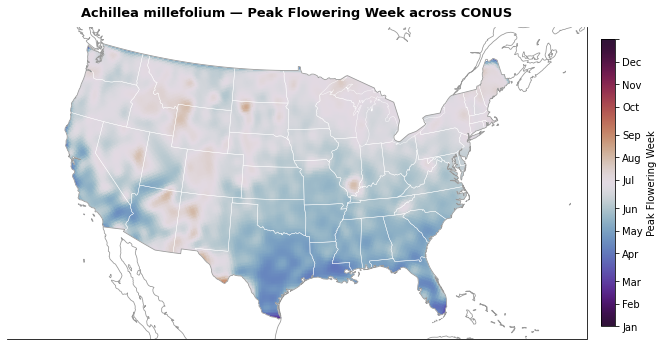

Saved fig_peak_flowering_week_smooth.png


In [6]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
import numpy as np
from scipy.ndimage import gaussian_filter
from scipy.interpolate import griddata

lon_grid = np.linspace(-125, -66, 400)
lat_grid = np.linspace(24, 50, 200)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)

peak_interp = griddata(
    points=(achillea_peak['centroid_lon'].values, achillea_peak['centroid_lat'].values),
    values=achillea_peak['week'].values,
    xi=(lon_mesh, lat_mesh),
    method='linear'
)
peak_smooth = gaussian_filter(np.nan_to_num(peak_interp, nan=0), sigma=3)
coverage = griddata(
    points=(achillea_peak['centroid_lon'].values, achillea_peak['centroid_lat'].values),
    values=np.ones(len(achillea_peak)),
    xi=(lon_mesh, lat_mesh),
    method='linear'
)
peak_smooth = np.where(np.isnan(coverage), np.nan, peak_smooth)

# Get US boundary
shpfilename = shpreader.natural_earth(
    resolution='50m', category='cultural', name='admin_0_countries'
)
reader = shpreader.Reader(shpfilename)
us_geom = [rec.geometry for rec in reader.records()
           if rec.attributes['NAME'] == 'United States of America'][0]

from shapely.geometry import box
world_box = box(-180, -90, 180, 90)
outside_us = world_box.difference(us_geom)

month_ticks  = [1, 5, 9, 14, 18, 22, 27, 31, 35, 40, 44, 48, 52]
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec','']

fig, ax = plt.subplots(
    figsize=(10, 6),
    facecolor='white',
    subplot_kw={'projection': ccrs.AlbersEqualArea(central_longitude=-96, standard_parallels=(29.5, 45.5))}
)
ax.set_facecolor('white')
ax.set_extent([-125, -66, 24, 50], crs=ccrs.PlateCarree())

im = ax.pcolormesh(
    lon_mesh, lat_mesh, peak_smooth,
    cmap='twilight_shifted', vmin=1, vmax=52,
    transform=ccrs.PlateCarree(), zorder=3
)

# Mask outside US
ax.add_geometries(
    [outside_us], crs=ccrs.PlateCarree(),
    facecolor='white', edgecolor='none', zorder=4
)

ax.add_feature(cfeature.STATES, linewidth=0.4, edgecolor='white', facecolor='none', zorder=5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='#999999', zorder=5)
ax.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor='#999999', facecolor='none', zorder=5)

ax.set_title('Achillea millefolium — Peak Flowering Week across CONUS',
             fontsize=13, fontweight='bold', pad=10)

cbar = plt.colorbar(im, ax=ax, shrink=0.7, pad=0.02)
cbar.set_label('Peak Flowering Week', fontsize=10)
cbar.set_ticks(month_ticks)
cbar.set_ticklabels(month_labels)

plt.tight_layout()
plt.savefig(OUT + "fig_peak_flowering_week_smooth.png", dpi=DPI, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved fig_peak_flowering_week_smooth.png")